# Brain Tissue Spectrum — Predicción

Predice el tipo celular de cada píxel de un `.imzML` nuevo usando el modelo, PCA, scaler y mapeo de clases generados por el notebook de entrenamiento.

- El binning del espectro replica exactamente `CellPreparator._clustering` del entrenamiento.
- Los nombres/orden de clase se leen de `class_to_idx.json` (no se hardcodean).
- El filtrado de fondo por KMeans es **opcional** (`APPLY_TISSUE_MASK`): actívalo si quieres descartar background antes de predecir; desactívalo para predecir literalmente todos los píxeles medidos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import os
import json
import pickle
import warnings
from pathlib import Path

import tensorflow as tf
from pyimzml.ImzMLParser import ImzMLParser
from scipy.ndimage import median_filter
from skimage.morphology import remove_small_objects
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore", message=".*Accession MS:.*")
warnings.filterwarnings("ignore", message=".*Accession IMS:.*")

%matplotlib inline

# Change path here!

## 1 · Rutas y parámetros

In [2]:
INPUT_IMZML = r"C:\Users\aitor\Desktop\Neural Lipotypes\data\BTS\Brain_positive.imzML"  

MODEL_DIR = Path(r"C:\Users\aitor\Desktop\GitHub - Lipotyper\TFG_Aitor\TFG_Aitor\neural_model\clean_cells\neural_network")

RESULTS_DIR = Path(r"C:\Users\aitor\Desktop\GitHub - Lipotyper\TFG_Aitor\TFG_Aitor\neural_model\results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BIN_LIMITS = (500.01094539, 1001.515)
#BIN_LIMITS = (650.0,850.0)
INTERVAL   = 0.012
THRESHOLD  = 50_000

APPLY_TISSUE_MASK = True   # True: aplica KMeans para descartar fondo antes de predecir
N_CLUSTERS = 3             # mismo valor que en entrenamiento

## 2 · Funciones de preprocesado (idénticas al entrenamiento)

In [3]:
def spec_normalization(spectrum):
    """Normalización TIC × 1e8."""
    return spectrum * 1.0e8 / (np.nansum(spectrum) + 1e-8)


def thresholded_BTS(spectrum, threshold=THRESHOLD):
    """Zeroes intensities at or below the threshold."""
    spec = spectrum.copy()
    spec[spec <= threshold] = 0.0
    return spec


def get_bin_edges(bins_limits=BIN_LIMITS, step=INTERVAL):
    start, stop = bins_limits
    return np.arange(start, stop + step, step)


BIN_EDGES = get_bin_edges()


def bin_spectrum(mz, intensity, bin_edges=BIN_EDGES):
    """
    Bina un espectro individual en el grid m/z común.
    Réplica exacta de CellPreparator._clustering del notebook de entrenamiento.
    Devuelve (mz_bins, intensity_binned), con NaN en los bins sin ningún m/z asignado.
    """
    mz_bins = (bin_edges[:-1] + bin_edges[1:]) / 2

    intensity = spec_normalization(intensity)
    intensity = thresholded_BTS(intensity)

    indices = np.digitize(x=mz, bins=bin_edges) - 1
    valid = (indices >= 0) & (indices < len(bin_edges) - 1)
    indices = indices[valid]
    intensity_values = intensity[valid]

    intensity_binned = np.bincount(indices, weights=intensity_values, minlength=len(mz_bins)).astype(np.float64)
    counts_per_bin = np.bincount(indices, minlength=len(mz_bins))
    intensity_binned[counts_per_bin == 0] = np.nan

    return mz_bins, intensity_binned

## 3 · Máscara de tejido (opcional)

Misma lógica corregida que en el notebook de entrenamiento: el cluster de **mayor** intensidad media es fondo (no al revés); de los clusters restantes, el más numeroso se toma como tejido.

In [4]:
def kmeans_tissue_mask(mean_intensity_image, n_clusters=N_CLUSTERS):
    max_x, max_y = mean_intensity_image.shape
    data = mean_intensity_image.reshape(-1)

    mask = ~np.isnan(data)
    labels = np.full(data.shape[0], -1, dtype=int)

    if mask.sum() == 0:
        return np.zeros((max_x, max_y), dtype=bool)

    model = KMeans(n_clusters=n_clusters, n_init=10, random_state=0)
    labels[mask] = model.fit_predict(data[mask].reshape(-1, 1))
    cluster_map = labels.reshape(max_x, max_y)

    centers = model.cluster_centers_.flatten()
    background_cluster = int(np.argmax(centers))   # fondo = mayor intensidad media

    counts = np.bincount(labels[mask], minlength=n_clusters)
    counts[background_cluster] = -1
    tissue_cluster = int(np.argmax(counts))         # tejido = más numeroso de los restantes

    valid_mask = cluster_map != -1
    filtered = median_filter(cluster_map, size=3)
    cluster_map[valid_mask] = filtered[valid_mask]

    tissue_mask = (cluster_map == tissue_cluster)
    tissue_mask = remove_small_objects(tissue_mask, max_size=128)

    return tissue_mask

## 4 · Cargar modelo, PCA, Scaler y mapeo de clases

In [5]:
model = tf.keras.models.load_model(MODEL_DIR / "model.keras")
print("Modelo cargado \u2713")

with open(MODEL_DIR / "pca.pkl", "rb") as f:
    pca = pickle.load(f)
print(f"PCA cargado \u2014 {pca.n_components_} componentes \u2713")

with open(MODEL_DIR / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
print("Scaler cargado \u2713")

with open(MODEL_DIR / "class_to_idx.json", "r") as f:
    class_to_idx = json.load(f)

n_classes = len(class_to_idx)
CLASS_NAMES = [None] * n_classes
for name, idx in class_to_idx.items():
    CLASS_NAMES[idx] = name

print(f"Clases ({n_classes}): {CLASS_NAMES}")

# Paleta de colores generada automáticamente para tantas clases como haya
_cmap = plt.get_cmap("tab10" if n_classes <= 10 else "tab20")
CLASS_COLORS = [mcolors.to_hex(_cmap(i % _cmap.N)) for i in range(n_classes)]

Modelo cargado ✓
PCA cargado — 100 componentes ✓
Scaler cargado ✓
Clases (5): ['Astro_Positivo', 'Microglia_Positivo', 'Neuron_Positivo', 'Oligo_Positivo', 'Plexo_Positivo']


## 5 · Leer y binar todos los píxeles del imzML

In [6]:
parser = ImzMLParser(INPUT_IMZML)
coords = parser.coordinates

max_x = max(c[0] for c in coords)
max_y = max(c[1] for c in coords)
print(f"Dimensiones: {max_x} x {max_y}  |  Pixeles: {len(coords)}")

n_bins = len(BIN_EDGES) - 1
print(f"Bins m/z: {n_bins}")

# NaN en posiciones sin datos (pixeles fuera del area medida)
kmatrix_spec = np.full((max_x, max_y, n_bins), np.nan, dtype=np.float32)
pixel_measured = np.zeros((max_x, max_y), dtype=bool)

for i, (x, y, z) in enumerate(coords):
    mz, intensity = parser.getspectrum(i)
    _, binned_intensity = bin_spectrum(mz, intensity)
    kmatrix_spec[x - 1, y - 1, :] = binned_intensity.astype(np.float32)
    pixel_measured[x - 1, y - 1] = True

print(f"Pixeles medidos: {pixel_measured.sum()}  |  sin datos: {(~pixel_measured).sum()}")

Dimensiones: 133 x 261  |  Pixeles: 34713
Bins m/z: 41793
Pixeles medidos: 34713  |  sin datos: 0


## 6 · Máscara de tejido y predicción (Claude)

Si `APPLY_TISSUE_MASK = True`, los píxeles de fondo se descartan (quedan como "Sin datos" en los mapas) antes de pasar por el modelo. Si `False`, se predice sobre todos los píxeles medidos, igual que tu notebook original.

In [7]:
if APPLY_TISSUE_MASK:
    kmatrix_int = np.nanmean(kmatrix_spec, axis=2)
    tissue_mask = kmeans_tissue_mask(kmatrix_int)
    # un pixel solo entra a prediccion si fue medido Y paso el filtro de tejido
    valid_pixels = pixel_measured & tissue_mask
    print(f"Pixeles tras filtro de tejido: {valid_pixels.sum()} (de {pixel_measured.sum()} medidos)")
else:
    valid_pixels = pixel_measured

X_flat = kmatrix_spec.reshape(-1, n_bins)
valid_flat = valid_pixels.reshape(-1)

X_valid = X_flat[valid_flat]
X_valid = np.nan_to_num(X_valid, nan=0.0)   # NaN -> 0 solo aqui, justo antes de entrar al modelo

X_scaled = scaler.transform(X_valid)
X_pca = pca.transform(X_scaled)

print(f"Shape entrada al modelo: {X_pca.shape}")

logits = model.predict(X_pca, batch_size=512, verbose=1)

pos_logits = np.clip(logits, 0, None)
total = pos_logits.sum(axis=1, keepdims=True)
safe_total = np.where(total == 0, 1.0, total)
probs = (pos_logits / safe_total) * 100

preds = np.argmax(probs, axis=1)

print("\nDistribucion de predicciones (clase dominante por pixel):")
for i, name in enumerate(CLASS_NAMES):
    count = (preds == i).sum()
    pct = 100 * count / len(preds) if len(preds) else 0.0
    print(f"  {name:12s}: {count:6d} px  ({pct:.1f} %)")

print("\nPorcentaje MEDIO por clase (sobre los pixeles predichos):")
for i, name in enumerate(CLASS_NAMES):
    vals = probs[:, i]
    print(f"  {name:20s}: media={vals.mean():5.1f}%  min={vals.min():5.1f}%  max={vals.max():5.1f}%")

Pixeles tras filtro de tejido: 19237 (de 34713 medidos)
Shape entrada al modelo: (19237, 100)
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Distribucion de predicciones (clase dominante por pixel):
  Astro_Positivo:      0 px  (0.0 %)
  Microglia_Positivo:      0 px  (0.0 %)
  Neuron_Positivo:    347 px  (1.8 %)
  Oligo_Positivo:      0 px  (0.0 %)
  Plexo_Positivo:  18890 px  (98.2 %)

Porcentaje MEDIO por clase (sobre los pixeles predichos):
  Astro_Positivo      : media= 13.5%  min=  0.0%  max= 47.7%
  Microglia_Positivo  : media=  1.0%  min=  0.0%  max= 35.8%
  Neuron_Positivo     : media= 10.9%  min=  0.0%  max= 96.1%
  Oligo_Positivo      : media=  0.0%  min=  0.0%  max=  0.0%
  Plexo_Positivo      : media= 74.6%  min=  0.0%  max=100.0%


### Diagnóstico rápido si una clase domina de forma sospechosa

Compara la probabilidad **media** de cada clase (no solo el argmax). Si todas las medias son parecidas y bajas (p.ej. todas entre 15-25%) pero una gana sistemáticamente por poco margen, el problema es de calibración/desequilibrio del modelo, no de preprocesado. Si una clase tiene probabilidad media absurdamente alta (>80-90%) en todos los píxeles incluidos los que deberían ser claramente otra cosa, sospecha de un desajuste entre `scaler.pkl`/`pca.pkl` y el modelo actual (regenera los tres juntos en el mismo entrenamiento).

In [8]:
print("Probabilidad MEDIA por clase (sobre los pixeles predichos):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:12s}: media={probs[:, i].mean():5.1f}%  min={probs[:, i].min():5.1f}%  max={probs[:, i].max():5.1f}%")

print("\nNumero de pixeles de ENTRENAMIENTO por clase (revisa class_to_idx.json / labels.csv de cada tipo):")
print("-> abre OUTPUT_PATH/<tipo>/labels.csv y compara len(df) entre clases.")
print("   Si una clase tiene muchos menos pixeles que las demas en el train, es la sospechosa nº1.")

Probabilidad MEDIA por clase (sobre los pixeles predichos):
  Astro_Positivo: media= 13.5%  min=  0.0%  max= 47.7%
  Microglia_Positivo: media=  1.0%  min=  0.0%  max= 35.8%
  Neuron_Positivo: media= 10.9%  min=  0.0%  max= 96.1%
  Oligo_Positivo: media=  0.0%  min=  0.0%  max=  0.0%
  Plexo_Positivo: media= 74.6%  min=  0.0%  max=100.0%

Numero de pixeles de ENTRENAMIENTO por clase (revisa class_to_idx.json / labels.csv de cada tipo):
-> abre OUTPUT_PATH/<tipo>/labels.csv y compara len(df) entre clases.
   Si una clase tiene muchos menos pixeles que las demas en el train, es la sospechosa nº1.


## 7 · Reconstruir mapas 2D de probabilidad (en %)

In [9]:
# prob_maps[i] -> mapa 2D de probabilidad (%) de la clase i; NaN = no predicho
prob_maps = np.full((n_classes, max_x * max_y), np.nan, dtype=np.float32)
prob_maps[:, valid_flat] = probs.T   # probs ya esta en % (0-100)
prob_maps = prob_maps.reshape(n_classes, max_x, max_y)

# logit_maps[i] -> mapa 2D de logits crudos (sin clip ni normalizar) de la clase i; NaN = no predicho
logit_maps = np.full((n_classes, max_x * max_y), np.nan, dtype=np.float32)
logit_maps[:, valid_flat] = logits.T
logit_maps = logit_maps.reshape(n_classes, max_x, max_y)

# Mapa de clase dominante (solo para pixeles predichos)
pred_map = np.full(max_x * max_y, -1, dtype=int)
pred_map[valid_flat] = preds
pred_map = pred_map.reshape(max_x, max_y)

print("Mapas 2D construidos \u2713")

Mapas 2D construidos ✓


## 8 · Plot: mapa de clase dominante (secundario)

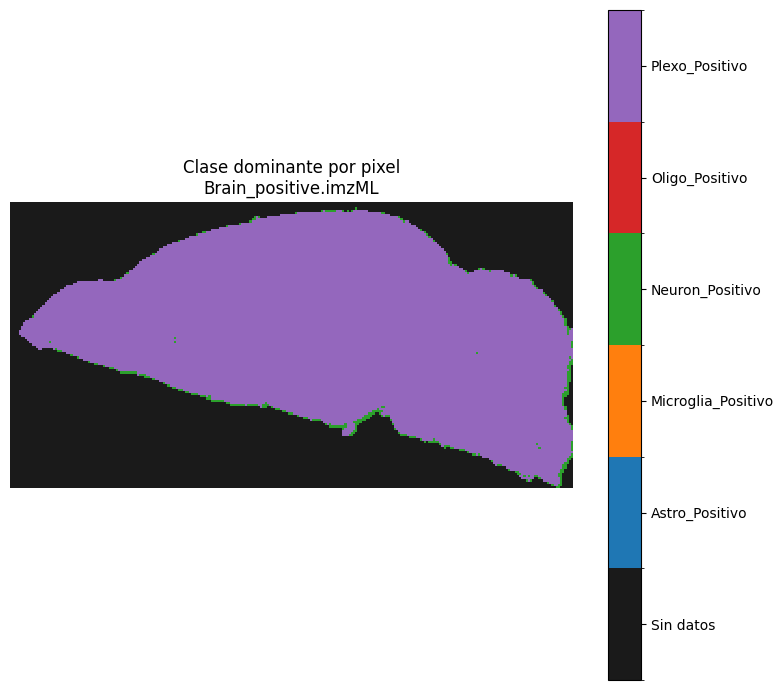

In [10]:
cmap_disc = mcolors.ListedColormap(["#1a1a1a"] + CLASS_COLORS)   # negro = sin datos/no predicho
bounds = np.arange(-1.5, n_classes + 0.5, 1.0)
norm_disc = mcolors.BoundaryNorm(bounds, cmap_disc.N)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(pred_map, cmap=cmap_disc, norm=norm_disc, interpolation="none")
cbar = plt.colorbar(im, ax=ax, ticks=np.arange(-1, n_classes))
cbar.ax.set_yticklabels(["Sin datos"] + CLASS_NAMES, fontsize=10)
ax.set_title(f"Clase dominante por pixel\n{os.path.basename(INPUT_IMZML)}", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{Path(INPUT_IMZML).stem}_clase_dominante.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 · Plot principal: porcentaje de cada tipo celular

Este es el que te interesa. Estilo: colormap tipo "jet", **escala autoajustada por panel** (no fija a 0-100, igual que en tu imagen de referencia), fondo blanco fuera del tejido, panel final "Global percentage" = confianza de la predicción (probabilidad de la clase ganadora) por pixel. Se guarda únicamente en `RESULTS_DIR`.

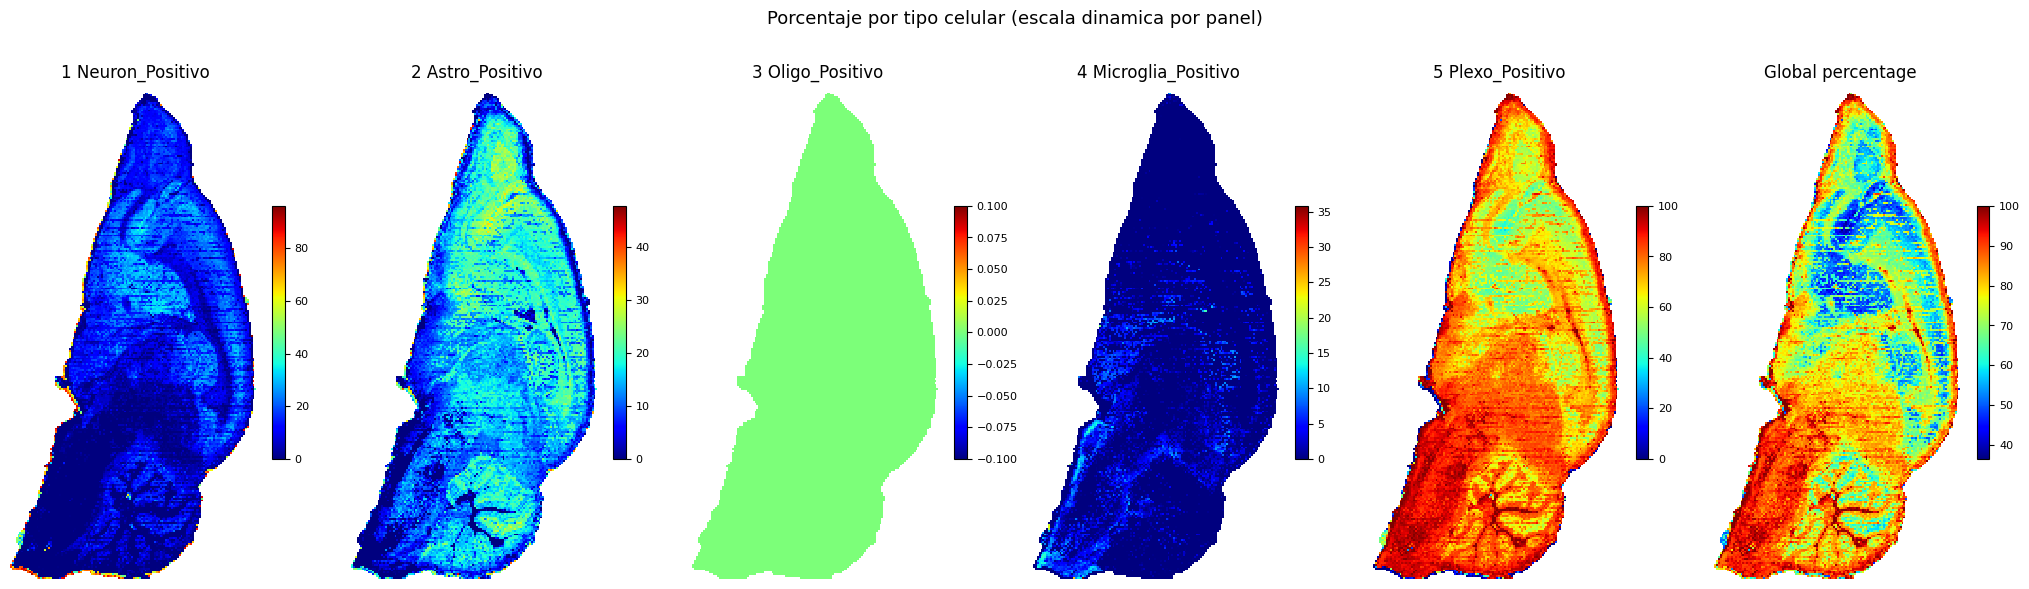

Guardado: C:\Users\aitor\Desktop\GitHub - Lipotyper\TFG_Aitor\TFG_Aitor\neural_model\results\Brain_positive_porcentaje_clases.png


In [11]:
# -- Orientacion de la imagen de salida --------------------------------------
# ROTATE_K: rotaciones de 90 grados antihorario (0=sin rotar, 1=90 anti, 3=90 horario)
# FLIP_AXIS: None=sin flip, 0=flip vertical, 1=flip horizontal
ROTATE_K  = 3
FLIP_AXIS = None

# -- Orden de los paneles (debe coincidir con nombres exactos en CLASS_NAMES) -
# Pon aqui el orden que quieras ver de izquierda a derecha.
# Si un nombre no existe en CLASS_NAMES se ignora; los que falten se añaden al final.
PANEL_ORDER = [
    "Neuron_Positivo",
    "Astro_Positivo",
    "Oligo_Positivo",
    "Microglia_Positivo",
    "Plexo_Positivo",
]

def orient(arr2d, k=ROTATE_K, flip=FLIP_AXIS):
    out = np.rot90(arr2d, k=k)
    if flip is not None:
        out = np.flip(out, axis=flip)
    return out

def reorder_classes(names, preferred_order):
    """Reordena names segun preferred_order; los no listados van al final."""
    ordered = [n for n in preferred_order if n in names]
    rest    = [n for n in names if n not in ordered]
    return ordered + rest

DISPLAY_ORDER = reorder_classes(CLASS_NAMES, PANEL_ORDER)
display_indices = [CLASS_NAMES.index(n) for n in DISPLAY_ORDER]

def plot_maps(maps_2d, valid_mask, display_idx, display_names,
              suptitle, fname, vmin_global=None, vmax_global=None, show_global=True):
    """
    maps_2d      : (n_classes, max_x, max_y)  — indices originales
    display_idx  : orden de paneles a mostrar (indices en maps_2d)
    display_names: etiquetas en ese mismo orden
    """
    jet = plt.get_cmap("jet").copy()
    jet.set_bad(color="white")

    valid_oriented = orient(valid_mask)
    panels = len(display_idx) + (1 if show_global else 0)
    fig, axes = plt.subplots(1, panels, figsize=(3.4 * panels, 6))
    axes = np.atleast_1d(axes)

    for panel, (idx, title) in enumerate(zip(display_idx, display_names)):
        ax = axes[panel]
        data = orient(maps_2d[idx].copy())
        data_masked = np.ma.masked_where(~valid_oriented, data)
        vals = maps_2d[idx][valid_mask]
        vmin = vmin_global if vmin_global is not None else (vals.min() if vals.size else 0)
        vmax = vmax_global if vmax_global is not None else (vals.max() if vals.size else 1)
        im = ax.imshow(data_masked, cmap=jet, vmin=vmin, vmax=vmax, interpolation="none")
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)
        ax.set_title(f"{panel+1} {title}", fontsize=12)
        ax.axis("off")

    if show_global:
        # Confianza de la prediccion = probabilidad de la clase ganadora por pixel
        gp = orient(maps_2d.max(axis=0).copy())
        gp_masked = np.ma.masked_where(~valid_oriented, gp)
        vals_g = maps_2d.max(axis=0)[valid_mask]
        vmin_g = vmin_global if vmin_global is not None else (vals_g.min() if vals_g.size else 0)
        vmax_g = vmax_global if vmax_global is not None else (vals_g.max() if vals_g.size else 1)
        ax = axes[-1]
        im = ax.imshow(gp_masked, cmap=jet, vmin=vmin_g, vmax=vmax_g, interpolation="none")
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)
        ax.set_title("Global percentage", fontsize=12)
        ax.axis("off")

    fig.suptitle(suptitle, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Guardado: {RESULTS_DIR / fname}")


stem = Path(INPUT_IMZML).stem

plot_maps(
    prob_maps, valid_pixels, display_indices, DISPLAY_ORDER,
    suptitle="Porcentaje por tipo celular (escala dinamica por panel)",
    fname=f"{stem}_porcentaje_clases.png",
    show_global=True
)

## 9b · Diagnóstico (opcional): logits crudos por clase

Mapa de los logits sin procesar (antes del `clip(0, None)` y la normalización). Útil solo para depurar el modelo: la escala **no** representa porcentajes ni probabilidades, y es normal que aparezcan valores negativos (salida cruda de la red, sin acotar en 0).

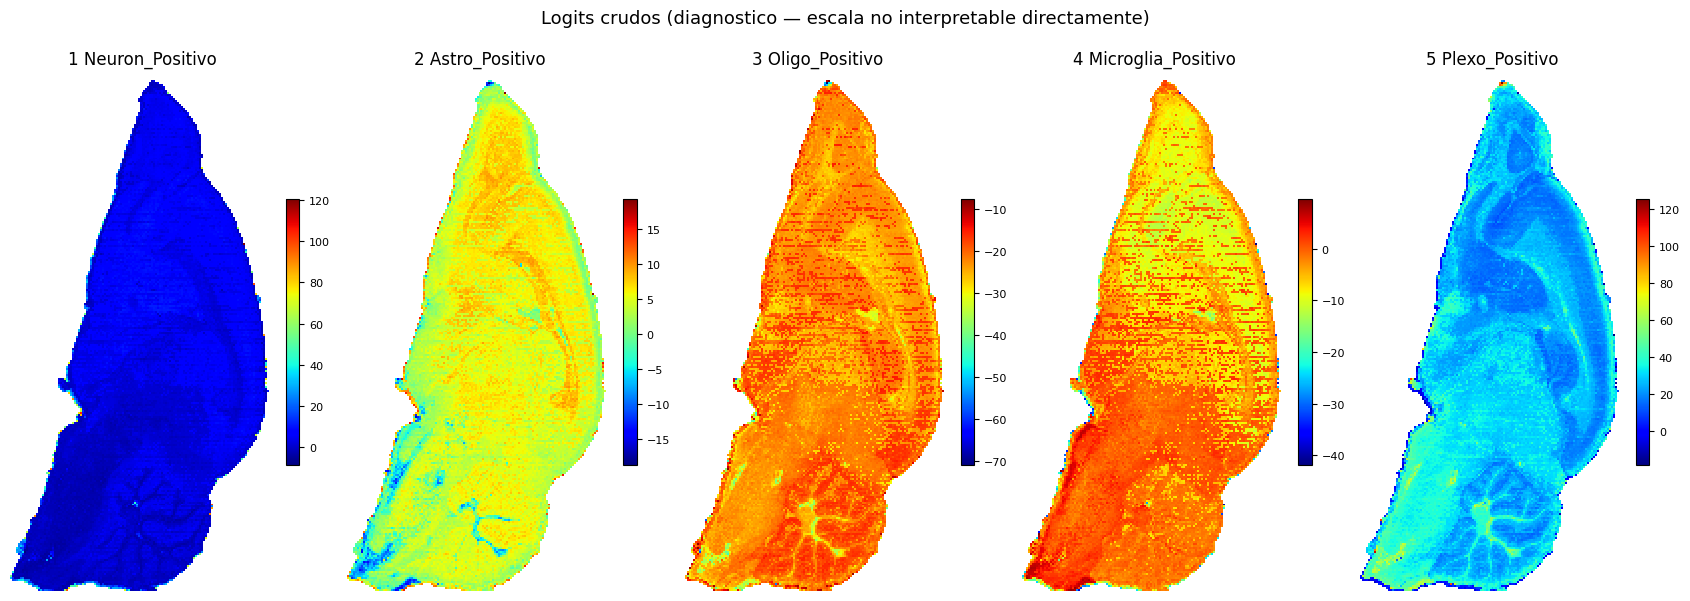

Guardado: C:\Users\aitor\Desktop\GitHub - Lipotyper\TFG_Aitor\TFG_Aitor\neural_model\results\Brain_positive_logits_crudos.png


In [12]:
plot_maps(
    logit_maps, valid_pixels, display_indices, DISPLAY_ORDER,
    suptitle="Logits crudos (diagnostico \u2014 escala no interpretable directamente)",
    fname=f"{stem}_logits_crudos.png",
    show_global=False
)

## 10 · Plot: mapa RGB combinado (secundario, opcional)

Elige 3 clases por nombre (no por índice, para evitar errores si cambia el orden).

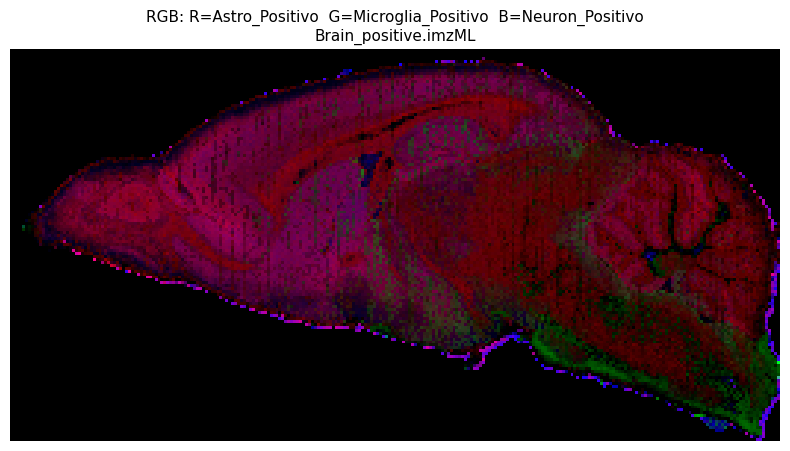

In [13]:
# Cambia estos nombres por las 3 clases que quieras comparar
NAME_R, NAME_G, NAME_B = CLASS_NAMES[0], CLASS_NAMES[1 % n_classes], CLASS_NAMES[2 % n_classes]

IDX_R = class_to_idx[NAME_R]
IDX_G = class_to_idx[NAME_G]
IDX_B = class_to_idx[NAME_B]


def norm01(arr):
    """Normaliza a [0,1] ignorando NaN."""
    mn, mx = np.nanmin(arr), np.nanmax(arr)
    return (arr - mn) / (mx - mn + 1e-8)


R = norm01(prob_maps[IDX_R])
G = norm01(prob_maps[IDX_G])
B = norm01(prob_maps[IDX_B])

for channel in [R, G, B]:
    channel[~valid_pixels] = 0.0

rgb = np.stack([R, G, B], axis=-1)

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(rgb, interpolation="none")
ax.set_title(
    f"RGB: R={NAME_R}  G={NAME_G}  B={NAME_B}\n{os.path.basename(INPUT_IMZML)}",
    fontsize=11
)
ax.axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{Path(INPUT_IMZML).stem}_rgb.png", dpi=150, bbox_inches="tight")
plt.show()

## 11 · Exportar CSV con resultados por píxel (secundario, opcional)

In [14]:
ys_idx, xs_idx = np.where(valid_pixels)

df_out = pd.DataFrame({
    "x": xs_idx + 1,   # 1-indexed, igual que en el resto del pipeline
    "y": ys_idx + 1,
    "predicted_class": preds,
    "predicted_label": [CLASS_NAMES[p] for p in preds],
})

for i, name in enumerate(CLASS_NAMES):
    df_out[f"pct_{name}"] = np.round(probs[:, i], 2)

output_csv = Path(INPUT_IMZML).with_suffix(".predictions.csv")
df_out.to_csv(output_csv, sep=";", index=False)
print(f"Guardado: {output_csv}")
df_out.head(10)

Guardado: C:\Users\aitor\Desktop\Neural Lipotypes\data\BTS\Brain_positive.predictions.csv


,x,y,predicted_class,predicted_label,pct_Astro_Positivo,pct_Microglia_Positivo,pct_Neuron_Positivo,pct_Oligo_Positivo,pct_Plexo_Positivo
0,161,4,2,Neuron_Positivo,18.270000,0.0,41.389999,0.0,40.340000
1,145,5,2,Neuron_Positivo,9.110000,0.0,90.889999,0.0,0.000000
2,146,5,4,Plexo_Positivo,0.000000,0.0,3.460000,0.0,96.540001
3,147,5,2,Neuron_Positivo,25.410000,0.0,68.580002,0.0,6.010000
4,148,5,2,Neuron_Positivo,20.760000,0.0,73.879997,0.0,5.360000
5,149,5,2,Neuron_Positivo,14.240000,0.0,85.760002,0.0,0.000000
6,150,5,2,Neuron_Positivo,24.870001,0.0,45.119999,0.0,30.010000
7,151,5,2,Neuron_Positivo,14.760000,0.0,85.239998,0.0,0.000000
8,152,5,4,Plexo_Positivo,5.120000,0.0,5.590000,0.0,89.300003
9,153,5,4,Plexo_Positivo,0.000000,0.0,2.420000,0.0,97.580002
